# Images – To Do List



Prior to starting this problem, be sure to enable the GPU runtime processing in your Jupyter notebook.



## Problem Definition


Binary classification using pictures of dogs and cats in a NumPy Array to predict the image of a cat or a dog.  The target y is 1, and 0 for each annimal and X = pictures.  After checking the plotted images, Cat = 1 and Dog = 0.


In [1]:
import pandas as pd
import numpy as np

## Data Collection



* Load pickled data from X.pickle and y.pickle from the AWS S3 bucket.



In [2]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

This is a four dimensional array with 24,946 images in the stack.  Each image is 100 pixels tall and 100 pixels wide and only 1 color channel, grayscale.

In [4]:
image_array.shape

(24946, 100, 100, 1)

Loading y pickled data.

In [5]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [6]:
target = pd.read_pickle( target_url )
type(target)


list

Single dog image

In [7]:
image_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg'

## Data Cleaning



* Scale the values in X so that they fall between 0 and 1 by dividing by 255.



In [8]:
#check array of image in index 0

image_array[0].shape

(100, 100, 1)

In [9]:
image_array = image_array / 255

In [10]:
image_array.max(), image_array.min()

(np.float64(1.0), np.float64(0.0))

check y list convert to array

In [11]:
target[0]

0

In [12]:
len(target)

24946

In [13]:
target = np.array(target)

In [14]:
target.shape

(24946,)

## Exploratory Data Analysis



* Look at the shape of X and y. Ensure that X is 4 dimensional.

* Plot a few ( >5 ) of the images in X using `plt.imshow()`.

* Look at the response values in y for those images.

* Hint: you may want to start with a random subset to get familiar with the process of building a NN.  Then go through the process again with the full set.



Look at the shape of X and y. Ensure that X is 4 dimensional.

In [15]:
image_array.shape

(24946, 100, 100, 1)

Check y shape, np.unique and target.sum for practice

In [16]:
target.shape

(24946,)

In [17]:
np.unique(target, return_counts = True)

(array([0, 1]), array([12470, 12476]))

In [18]:
target.sum()

np.int64(12476)

Plot a few ( >5 ) of the images in X using plt.imshow().

Mapping:


1.   Cats = 1
2.   Dogs = 0



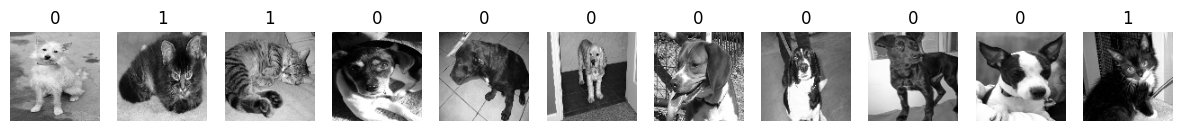

In [19]:
import matplotlib.pyplot as plt

# Create a grid for 11 images
fig, axes = plt.subplots(1, 11, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(image_array[i], cmap='gray')  # Display the image
    ax.axis("off")  # Hide the axis lines
    ax.set_title(target[i])


plt.show()

## Data Processing



* Split X and y into training and testing sets.

*  Build a convolutional neural network with the following:
  * Sequential layers
  * At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
  * A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
  * A dense output layer using the 'sigmoid' activation function.
  Note: you can play around with the number of layers and nodes to try to get better performance.

* Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

* Fit your model using the training set.

* Evaluate your model using the testing set.

* Plot the distribution of probabilities for the testing set.

* Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: [numpy.reshape]( https://numpy.org/doc/stable/reference/generated/numpy.reshape.html )

* Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

* Use the neural network you created to predict whether the image is a dog or a cat.



Split X and y intor training and testing sets


In [20]:
from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing
image_array_train, image_array_test, target_train, target_test = train_test_split(
    image_array, target, test_size=0.2, random_state=42, stratify = target # stratify is not needed since y is balanced (array([0, 1]), array([12470, 12476])) including for practice
)

Convolutional neural network -
1. Sequential layers
2. At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
3. A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
4. A dense output layer using the 'sigmoid' activation function.

Note: you can play around with the number of layers and nodes to try to get better performance.

Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Initialize a sequential model
model = models.Sequential (
    [
        # First convolutional block: extracts 32 low-level features
        layers.Conv2D(
            32, (3, 3), activation="relu", input_shape=( 100, 100, 1)
        ),  # input_shape images
        layers.MaxPooling2D((2, 2)),
        # Second convolutional block: extracts 64 higher-level features
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Flattening the 2D maps into a 1D vector for classification
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        # Output layer: change units to match your number of classes
        layers.Dense(1, activation="sigmoid"),
    ]
)

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Print model summary to verify dimensions
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,185,729 (8.34 MB)

 Trainable params: 2,185,729 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

Fit your model using the training set.

In [22]:
history_5 = model.fit(
    image_array_train, target_train, epochs=5, validation_data=(image_array_test, target_test)
)

Epoch 1/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.6297 - loss: 0.6314 - val_accuracy: 0.7216 - val_loss: 0.5575
Epoch 2/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7633 - loss: 0.4908 - val_accuracy: 0.7701 - val_loss: 0.4729
Epoch 3/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8055 - loss: 0.4206 - val_accuracy: 0.7926 - val_loss: 0.4483
Epoch 4/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8453 - loss: 0.3492 - val_accuracy: 0.7824 - val_loss: 0.4749
Epoch 5/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8855 - loss: 0.2679 - val_accuracy: 0.7862 - val_loss: 0.4938


Evaluate your model using the testing set.

In [23]:
model.evaluate(image_array_test, target_test)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7862 - loss: 0.4938


[0.49384844303131104, 0.7861723303794861]

Plot the distribution of probabilities for the testing set.  Shows how confident the model is but does not mean it is correct or accurate

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


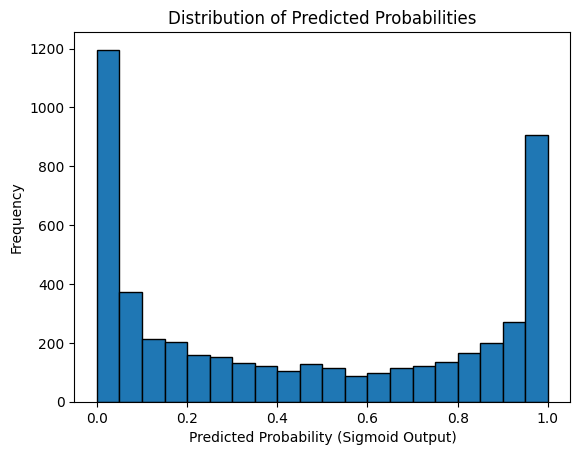

In [24]:
# Get the predictions and flatten them into a 1D array
probabilities = model.predict(image_array_test).flatten()

# Plot the probabilities using matplotlib's histogram
plt.hist(probabilities, bins=20, edgecolor="black")
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability (Sigmoid Output)")
plt.ylabel("Frequency")
plt.show()


Rerun sequential and compile

In [25]:
# Initialize a sequential
model = models.Sequential(
 [    # First convolutional block: extracts 32 low-level features
      layers.Conv2D(
      32, (3, 3), activation="relu", input_shape=( 100, 100, 1)
      ),
      # input_shape images
            layers.MaxPooling2D((2, 2)),
      # Second convolutional block: extracts 64 higher-level features
           layers.Conv2D(64, (3, 3), activation="relu"),
      layers.MaxPooling2D((2, 2)),
      # Flattening the 2D maps into a 1D vector for classification
           layers.Flatten(),
      layers.Dense(64, activation="relu"),
      # Output layer: change units to match your number of classes
        layers.Dense(1, activation="sigmoid"),
 ]

)
# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

 # Print model summary to verify dimensions
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,185,729 (8.34 MB)

 Trainable params: 2,185,729 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history_20 = model.fit(
    image_array_train, target_train, epochs=20, validation_data=(image_array_test, target_test)
)

Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6825 - loss: 0.5867 - val_accuracy: 0.7423 - val_loss: 0.5167
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7851 - loss: 0.4593 - val_accuracy: 0.7517 - val_loss: 0.4980
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8188 - loss: 0.3962 - val_accuracy: 0.8064 - val_loss: 0.4297
Epoch 4/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8579 - loss: 0.3251 - val_accuracy: 0.7874 - val_loss: 0.4685
Epoch 5/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8985 - loss: 0.2446 - val_accuracy: 0.7966 - val_loss: 0.4694
Epoch 6/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9412 - loss: 0.1553 - val_accuracy: 0.7930 - val_loss: 0.5870
Epoch 7/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9687 - loss: 0.0898 - val_accuracy: 0.7860 - val_loss: 0.6802
Epoch 8/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9823 - loss: 0.0550 - val_acc

In [27]:
model.evaluate(image_array_test, target_test)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7776 - loss: 1.4564


[1.4564491510391235, 0.7775551080703735]

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


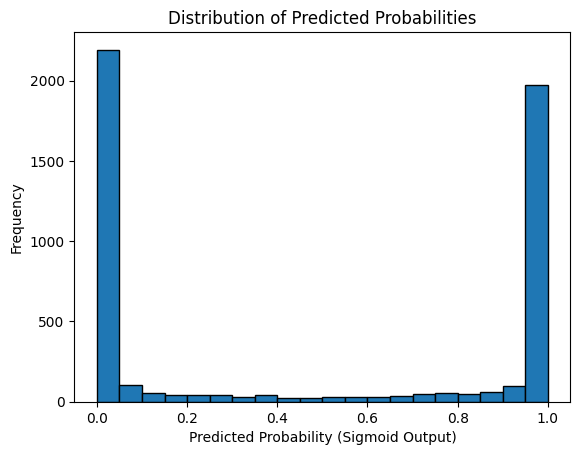

In [28]:
# the predictions and flatten them into a 1D array
probabilities = model.predict(image_array_test).flatten()

# Plot the probabilities using matplotlib's histogram
plt.hist(probabilities, bins=20, edgecolor="black")
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability (Sigmoid Output)")
plt.ylabel("Frequency")
plt.show()


Running Epoch 3 - the best model

In [1]:
# Initialize a sequential model
model = models.Sequential (
    [
        # First convolutional block: extracts 32 low-level features
        layers.Conv2D(
            32, (3, 3), activation="relu", input_shape=( 100, 100, 1)
        ),  # input_shape images
        layers.MaxPooling2D((2, 2)),
        # Second convolutional block: extracts 64 higher-level features
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Flattening the 2D maps into a 1D vector for classification
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        # Output layer: change units to match your number of classes
        layers.Dense(1, activation="sigmoid"),
    ]
)

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Print model summary to verify dimensions
model.summary()


NameError: name 'models' is not defined

In [ ]:
history_20 = model.fit(
    image_array_train, target_train, epochs= 3, validation_data=(image_array_test, target_test)
)

In [ ]:
model.evaluate(image_array_test, target_test)

In [ ]:
# the predictions and flatten them into a 1D array
probabilities = model.predict(image_array_test).flatten()

# Plot the probabilities using matplotlib's histogram
plt.hist(probabilities, bins=20, edgecolor="black")
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability (Sigmoid Output)")
plt.ylabel("Frequency")
plt.show()


Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: numpy.reshape

Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

Use the neural network you created to predict whether the image is a dog or a cat.

## Communication of Results



* Communicate the results of your analysis.



## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.